<a href="https://colab.research.google.com/github/NoeliaFerrero/Comi-96160-Data-Science-II-Machine-Learning-para-la-Ciencia-de-Datos-Diplomaturas/blob/main/Semana%2010%20Analisis%20Multivariado/Mini_Notebook_Practica_Analisis_Multivariado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧩 Mini práctica — Análisis Multivariado
### De la vida real al dato

La idea de este notebook no es aprender algoritmos de memoria.

Vamos a practicar una pregunta mucho más importante:

> **¿Qué problema quiero resolver y qué variables necesito mirar juntas?**

Vamos a trabajar con un caso sencillo de clientes de una tienda online.

**Importante:** primero intentá responder las preguntas con tus palabras. Después ejecutá el código para mirar los datos.


## 1. Nuestro caso

Una tienda online quiere entender el comportamiento de sus clientes.

Tenemos estas variables:

- `edad`: edad del cliente
- `ingreso_mensual`: ingreso estimado
- `visitas_web`: cantidad de visitas al sitio
- `compras_ult_6m`: cantidad de compras en los últimos 6 meses
- `gasto_ult_6m`: dinero gastado en los últimos 6 meses
- `abandono`: si dejó de comprar (`1`) o no (`0`)

### Antes de mirar los datos 🤔

**Pregunta 1:** Si solamente miramos `gasto_ult_6m`, ¿qué información estamos dejando afuera?

**Pregunta 2:** ¿Qué variables podrían ayudarnos a entender mejor el gasto?

**Pregunta 3:** Si quisiéramos predecir `abandono`, ¿cuál sería nuestra variable objetivo?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "edad": [22,25,31,35,42,48,52,28,39,45,23,33,57,41,29,36,50,27,44,53],
    "ingreso_mensual": [450,520,850,1100,1600,2100,2400,700,1350,1800,480,950,2800,1500,620,1250,2300,560,1700,2600],
    "visitas_web": [18,25,31,28,15,10,8,35,20,12,30,27,6,18,33,24,9,29,14,7],
    "compras_ult_6m": [2,3,5,6,7,8,9,4,6,7,3,5,10,6,4,5,8,3,7,9],
    "gasto_ult_6m": [90,130,260,390,620,780,950,210,480,650,120,300,1100,520,190,410,820,160,590,980],
    "abandono": [1,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0]
})

df.head()


,edad,ingreso_mensual,visitas_web,compras_ult_6m,gasto_ult_6m,abandono
0,22,450,18,2,90,1
1,25,520,25,3,130,1
2,31,850,31,5,260,0
3,35,1100,28,6,390,0
4,42,1600,15,7,620,0


## 2. Primera mirada: ¿una variable alcanza?

Vamos a mirar algunas relaciones.

### Pregunta antes de ejecutar:

Si queremos entender `gasto_ult_6m`, ¿cuál de estas relaciones te parece más interesante?

A. Edad → gasto  
B. Visitas web → gasto  
C. Compras → gasto  
D. Mirar las tres juntas

No hay que adivinar el resultado. La idea es pensar **qué pregunta de negocio estamos haciendo**.


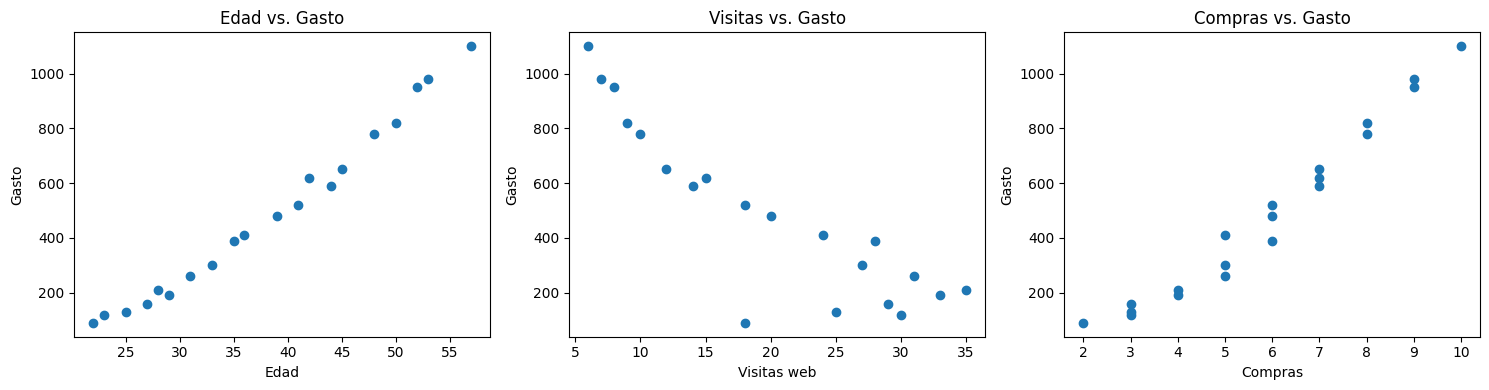

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df["edad"], df["gasto_ult_6m"])
axes[0].set_title("Edad vs. Gasto")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Gasto")

axes[1].scatter(df["visitas_web"], df["gasto_ult_6m"])
axes[1].set_title("Visitas vs. Gasto")
axes[1].set_xlabel("Visitas web")
axes[1].set_ylabel("Gasto")

axes[2].scatter(df["compras_ult_6m"], df["gasto_ult_6m"])
axes[2].set_title("Compras vs. Gasto")
axes[2].set_xlabel("Compras")
axes[2].set_ylabel("Gasto")

plt.tight_layout()
plt.show()


### 💬 Para pensar

¿Encontraste alguna relación que parezca más clara?

**Ojo:** que una relación parezca clara en un gráfico no significa que ya tengamos una explicación causal.

Ahora vamos a dar el salto importante: **usar varias variables juntas**.


## 3. Regresión lineal múltiple - versión amigable

Nuestra pregunta de negocio:

> **¿Podemos estimar cuánto gastará un cliente utilizando varias características?**

Vamos a usar:

- edad
- ingreso mensual
- visitas web
- compras de los últimos 6 meses

Y queremos estimar:

- gasto de los últimos 6 meses

No hace falta interpretar cada número todavía. La idea es reconocer la estructura:

**varias variables explicativas → una variable resultado**


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[["edad", "ingreso_mensual", "visitas_web", "compras_ult_6m"]]
y = df["gasto_ult_6m"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)

print("R² del modelo:", round(r2_score(y_test, predicciones), 2))


R² del modelo: 0.97


### 🧠 ¿Qué tenemos que aprender de este ejercicio?

No hace falta quedarse hoy con la fórmula.

Quedate con esta idea:

> **La regresión múltiple utiliza varias variables para estimar una variable resultado.**

En este ejemplo:

**edad + ingreso + visitas + compras → gasto**

Y eso es justamente lo que diferencia a la regresión múltiple de una regresión con una sola variable explicativa.


## 4. Ahora pensemos como DS 🔎

La tienda cambia la pregunta:

> **¿Qué clientes podrían abandonar?**

Ahora nuestra variable objetivo es `abandono`.

### Pregunta:

¿Cuáles de estas variables podrían ser útiles para analizar el abandono?

- edad
- ingreso
- visitas
- compras
- gasto

Elegí al menos 3 y explicá **por qué**.


In [5]:
df.groupby("abandono")[[
    "edad", "ingreso_mensual", "visitas_web",
    "compras_ult_6m", "gasto_ult_6m"
]].mean().round(1)


,edad,ingreso_mensual,visitas_web,compras_ult_6m,gasto_ult_6m
abandono,,,,,
0,43.3,1735.7,16.4,7.0,632.1
1,25.7,555.0,28.3,3.2,150.0


### 💬 Mirá la tabla y compará

Tenemos dos grupos:

- `abandono = 0` → clientes que no abandonaron
- `abandono = 1` → clientes que abandonaron

**Pregunta:**

¿Qué diferencias observás entre los grupos?

No hace falta sacar una conclusión definitiva. Solamente describí lo que muestran los datos.


## 5. ¿Y dónde aparece lo multivariado?

Hasta ahora podríamos mirar una variable por vez.

Pero una pregunta más interesante sería:

> **¿Qué combinación de características está asociada con el abandono?**

Ahí empezamos a pensar de manera multivariada.

No estamos diciendo que una variable *cause* el abandono.

Estamos preguntando si **varias características, consideradas conjuntamente, ayudan a explicar o predecir el resultado**.


## 6. ¿Y las otras siglas?

En la clase vimos otras técnicas:

| Técnica | Idea general |
|---|---|
| Regresión lineal múltiple | Varias variables explicativas para estimar un resultado |
| PCR | Componentes principales + regresión |
| PLSR | Regresión útil cuando hay muchas variables y posible correlación |
| ANN | Redes que aprenden patrones, especialmente relaciones no lineales |
| SVM | Clasificación/regresión; en clasificación busca separar clases |

### Mini desafío

Sin buscar en Google:

1. ¿Cuál usarías si querés estimar una variable numérica con varias variables explicativas?
2. ¿Cuál asociarías con redes neuronales?
3. ¿Cuál asociarías con separar clientes en categorías?
4. ¿Cuál combina componentes principales con regresión?


## 7. 🎯 Cierre: pensá antes de elegir el algoritmo

Completá estas frases:

**Mi problema de negocio es:** ...

**Quiero conocer / predecir:** ...

**Las variables que tengo disponibles son:** ...

**Creo que podría ser útil analizar estas variables juntas porque:** ...

**La técnica que investigaría primero sería:** ...

### ⭐ Regla de oro

> **Primero el problema. Después los datos. Recién después, el algoritmo.**

No necesitamos usar Machine Learning porque sí.

Necesitamos una herramienta que tenga sentido para la pregunta que queremos responder.
